# 01: Dataset Exploration & Validation 🔍

This notebook serves as the foundational **Exploratory Data Analysis (EDA)** for CardioSense. We will investigate the structure, quality, and patterns within the cardiovascular disease dataset.

### 🎯 Goals
1.  **Data Loading:** Load the `cardio_train.csv` dataset correctly (handling the `;` delimiter).
2.  **Data Quality Check:** Inspect for missing values, duplicates, and correct data types.
3.  **Feature Transformation:** Convert the 'Age' column from days to years.
4.  **Distribution Analysis:** Visualize target balance (Disease vs. No Disease) and correlations.

### 🏗️ Components Used
* `pandas`: For data manipulation.
* `matplotlib` / `seaborn`: For visualizing distributions and correlations.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration for cleaner visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)

Pandas version: 2.3.3
NumPy version: 2.2.6
Seaborn version: 0.13.2


## 1. Data Loading

We will load the dataset from the `raw` directory.
**Note:** The dataset uses a semicolon (`;`) as a separator, not a standard comma.

In [2]:
# Load the dataset
# Adjust path if necessary: '..' goes up one level from 'notebooks/' to the root, then into 'data/raw/'
file_path = '../data/raw/cardio_train.csv'

try:
    df = pd.read_csv(file_path, sep=';')
    print("✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print(f"❌ File not found at {file_path}. Please check the path.")

✅ Dataset loaded successfully!
Shape: 70000 rows, 13 columns


## 2. Initial Inspection

Let's look at the first few rows and the data types to understand what we are dealing with.

In [3]:
# Display first 5 rows
display(df.head())

# Display info about columns and data types
print("\n--- Column Info ---")
df.info()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


## 📄 Dataset Description(from Kaggle)

This dataset contains medical information collected during routine health examinations.
It includes **objective**, **examination**, and **subjective** features used to predict the presence of **cardiovascular disease**.

### 🔍 Feature Categories

#### **1. Objective Features**

Factual, directly measured information.

| Feature    | Description                               | Type          |
| ---------- | ----------------------------------------- | ------------- |
| **Age**    | Age in days                               | `int`         |
| **Height** | Height in centimeters                     | `int`         |
| **Weight** | Weight in kilograms                       | `float`       |
| **Gender** | Male/Female encoded as categorical values | `categorical` |

---

#### **2. Examination Features**

Results obtained from medical tests.

| Feature         | Name                     | Simple Meaning                                                                                                                                                        | Why It Matters                                                                                                | Type      |
| --------------- | ------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- | --------- |
| **ap_hi**       | Systolic Blood Pressure  | The pressure in your blood vessels **when your heart beats**. Higher values mean the heart is pushing harder.                                                         | High systolic pressure can indicate **hypertension**, which increases risk of heart disease and stroke.       | `int`     |
| **ap_lo**       | Diastolic Blood Pressure | The pressure in your blood vessels **when your heart is resting** between beats.                                                                                      | High diastolic pressure also signals **hypertension**, while unusually low values can indicate health issues. | `int`     |
| **cholesterol** | Blood Cholesterol Level  | The amount of **fat-like substance** in your blood. Too much can block blood vessels. <br>• 1 = normal <br>• 2 = higher than normal <br>• 3 = much higher than normal | High cholesterol can lead to **clogged arteries**, increasing the chance of heart attack or stroke.           | `ordinal` |
| **gluc**        | Blood Glucose Level      | The amount of **sugar** in your blood. <br>• 1 = normal <br>• 2 = higher than normal <br>• 3 = much higher than normal                                                | High glucose can indicate **diabetes** or prediabetes, which strongly affects heart health.                   | `ordinal` |

---

#### **3. Subjective Features**

Self-reported lifestyle information.

| Feature    | Description                   | Type     |
| ---------- | ----------------------------- | -------- |
| **smoke**  | Smoking status (0/1)          | `binary` |
| **alco**   | Alcohol intake (0/1)          | `binary` |
| **active** | Physical activity level (0/1) | `binary` |

---

### 🎯 Target Variable

| Feature    | Description                                          | Type     |
| ---------- | ---------------------------------------------------- | -------- |
| **cardio** | Presence of cardiovascular disease (0 = no, 1 = yes) | `binary` |


### Observations:
* **Age** is in days (needs conversion).
* **Gender** is 1/2 (we need to determine which is Male/Female later, usually 1=Female, 2=Male in this specific dataset context, but we will treat it as categorical).
* **Cholesterol/Gluc** are categorical (1, 2, 3).
* **Target** is `cardio` (0 or 1).

## 3. Data Cleaning & Feature Engineering (Initial)

### 3.1 Drop 'id' Column
The `id` column is just an index and provides no predictive power.

In [4]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print("Dropped 'id' column.")

Dropped 'id' column.


### 3.2 Check for Missing Values & Duplicates

In [5]:
# Check for null values
null_counts = df.isnull().sum()
print("Missing Values:\n", null_counts[null_counts > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicates}")

Missing Values:
 Series([], dtype: int64)

Total Duplicate Rows: 24


*Note: If duplicates exist, we should generally remove them to prevent data leakage or bias, but we will strictly handle removal in the next Preprocessing notebook.*

### 3.3 Convert Age to Years
The `age` column is currently in days. We will create a new column `age_years` for better interpretability.

In [6]:
# Convert days to years (approx 365.25 days per year)
df['age_years'] = (df['age'] / 365.25).round().astype(int)

# Drop the original 'age' column (optional, but keeps dataframe clean)
# We will keep 'age' for now if needed, but 'age_years' is our primary focus.
display(df[['age', 'age_years']].head())

,age,age_years
0,18393,50
1,20228,55
2,18857,52
3,17623,48
4,17474,48


## 4. Statistical Summary

Let's look at the numerical distribution of our features.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0
alco,70000.0,0.053771,0.225568,0.0,0.0,0.0,0.0,1.0


**Potential Issues to Flag for Next Step:**
* **Systolic BP (`ap_hi`)**: Check min/max values. Negative values or values like 16020 are errors.
* **Diastolic BP (`ap_lo`)**: Similar checks needed.
* **Height/Weight**: Look for unrealistic outliers.

## 5. Visualizations

### 5.1 Target Class Balance
Is the dataset balanced? (Do we have equal numbers of sick vs. healthy patients?)

C:\Users\YASH\AppData\Local\Temp\ipykernel_25156\1930734691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='pastel')


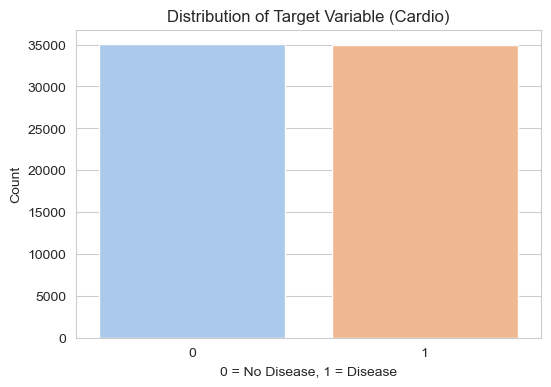

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df, palette='pastel')
plt.title('Distribution of Target Variable (Cardio)')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

# Print exact ratios
print(df['cardio'].value_counts(normalize=True))

### 5.2 Age Distribution
How does age relate to cardiovascular disease?

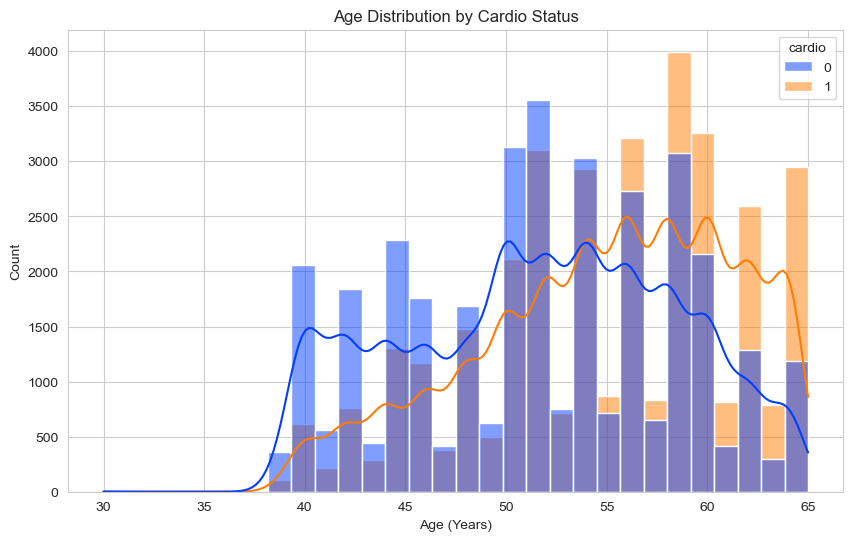

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age_years', hue='cardio', kde=True, bins=30, palette='bright')
plt.title('Age Distribution by Cardio Status')
plt.xlabel('Age (Years)')
plt.show()

### 5.3 Correlation Heatmap
Which features are most correlated with the target?

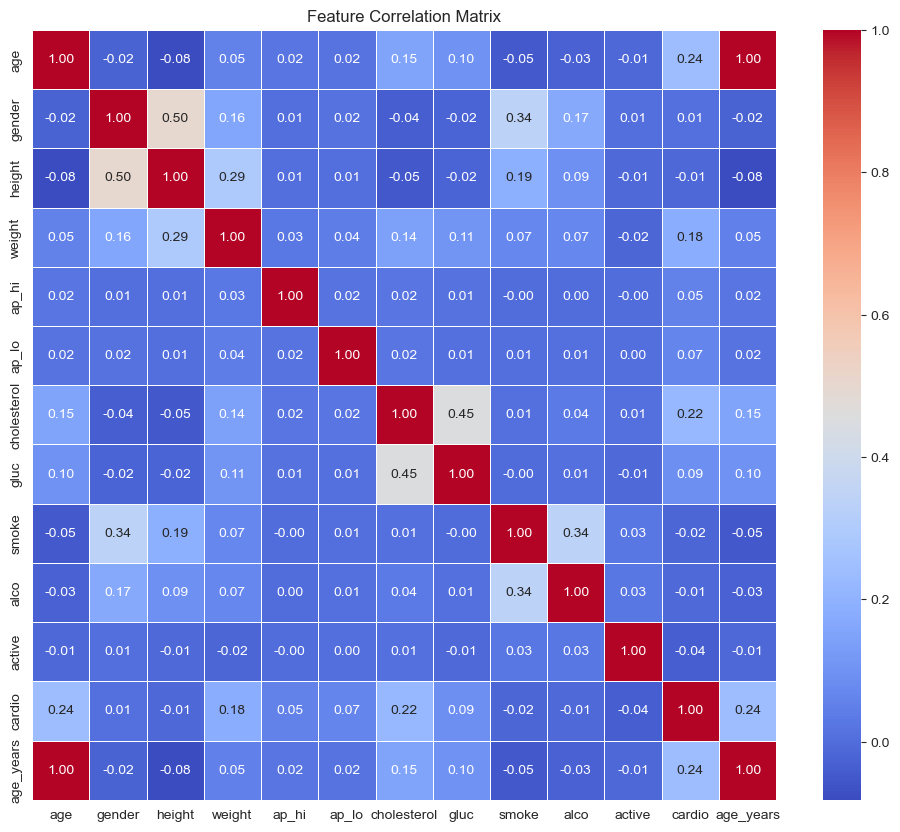

In [10]:
plt.figure(figsize=(12, 10))
# Calculate correlation matrix
corr_matrix = df.corr()

# Draw heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## 5.4 Categorical Features Analysis
Let's analyze how lifestyle choices and medical levels impact cardiovascular risk.
We will look at Cholesterol, Glucose, Smoking, Alcohol, and Physical Activity.

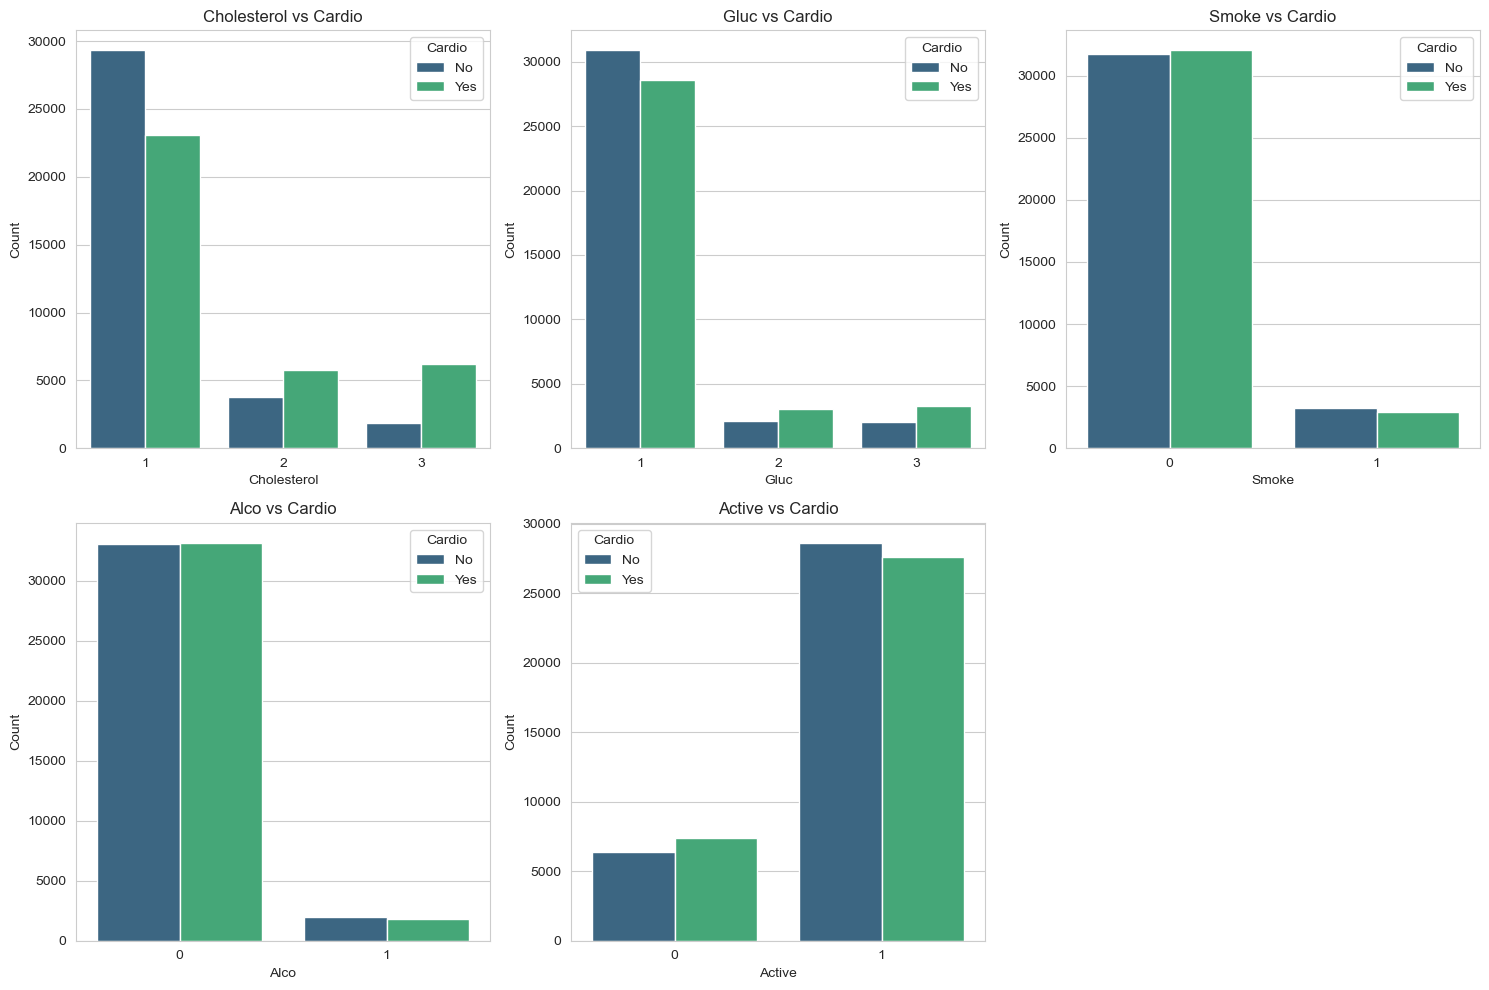

In [11]:
# Select categorical features
categorical_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=feature, hue='cardio', data=df, palette='viridis')
    plt.title(f'{feature.capitalize()} vs Cardio', fontsize=12)
    plt.xlabel(feature.capitalize())
    plt.ylabel('Count')
    plt.legend(title='Cardio', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

### Observations:
* **Cholesterol & Glucose:** As levels increase (1 -> 3), the ratio of sick people (1) significantly increases.
* **Activity:** People who are active (1) seem to have a slightly lower ratio of disease compared to inactive people.

## 5.5 Blood Pressure Sanity Check (The "Impossible" Values)
This is a critical step. Systolic BP (`ap_hi`) should always be higher than Diastolic BP (`ap_lo`).
Also, values like 10,000 or negative numbers are impossible. Let's visualize this error.

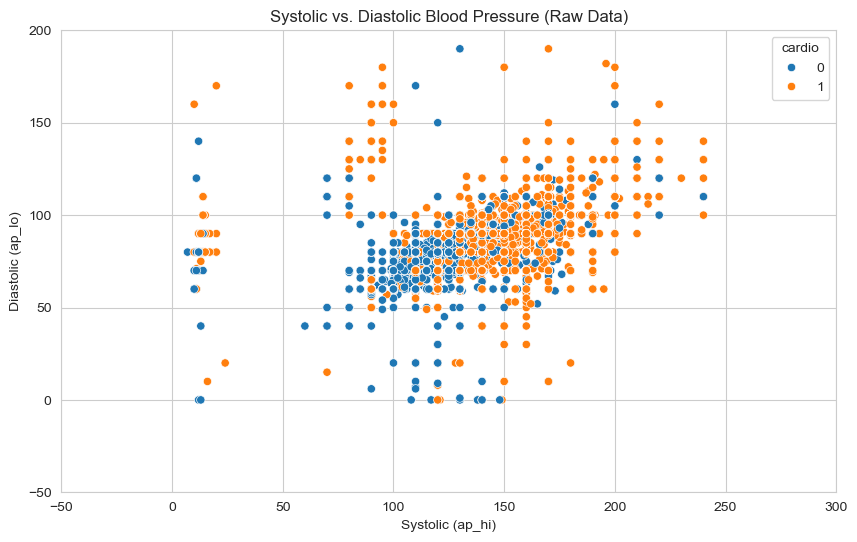

⚠️ Rows with impossible BP (Systolic < Diastolic or Negative): 1235


In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df, alpha=1)
plt.title('Systolic vs. Diastolic Blood Pressure (Raw Data)')
plt.xlabel('Systolic (ap_hi)')
plt.ylabel('Diastolic (ap_lo)')
# Limit axes to focus on the "normal-ish" range, but enough to show outliers clearly
plt.xlim(-50, 300)
plt.ylim(-50, 200)
plt.show()

# Count specific impossible cases
impossible_bp = df[(df['ap_hi'] < df['ap_lo']) | (df['ap_hi'] < 0) | (df['ap_lo'] < 0)]
print(f"⚠️ Rows with impossible BP (Systolic < Diastolic or Negative): {len(impossible_bp)}")

## 5.6 BMI Analysis (Temporary Feature)
Obesity is a major risk factor. Let's calculate BMI temporarily to see its distribution.
Formula: $BMI = \frac{Weight (kg)}{Height (m)^2}$

C:\Users\YASH\AppData\Local\Temp\ipykernel_25156\496368138.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cardio', y='bmi_temp', data=df, palette='muted', split=True)


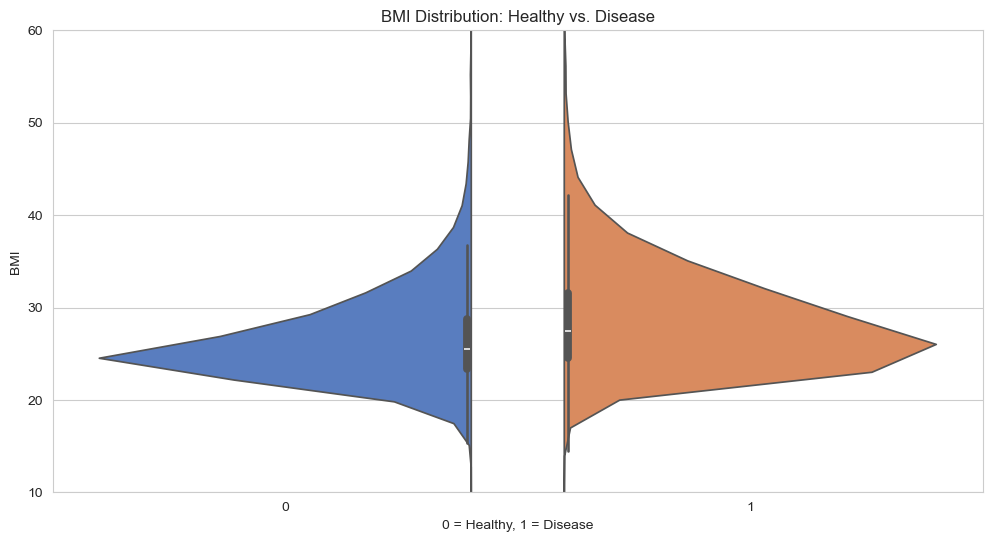

Median BMI for Healthy: 25.476660092044707
Median BMI for Sick: 27.47138397502601


In [13]:
# Calculate BMI
# Height is in cm, so divide by 100 to get meters
df['bmi_temp'] = df['weight'] / ((df['height'] / 100) ** 2)

plt.figure(figsize=(12, 6))
sns.violinplot(x='cardio', y='bmi_temp', data=df, palette='muted', split=True)
plt.title('BMI Distribution: Healthy vs. Disease')
plt.ylabel('BMI')
plt.xlabel('0 = Healthy, 1 = Disease')
# Limit Y-axis to ignore extreme outliers for the plot readability
plt.ylim(10, 60)
plt.show()

print("Median BMI for Healthy:", df[df['cardio']==0]['bmi_temp'].median())
print("Median BMI for Sick:", df[df['cardio']==1]['bmi_temp'].median())

## 5.7 Outlier Visualization (Height & Weight)
We likely have data entry errors (e.g., a height of 50cm for an adult).

C:\Users\YASH\AppData\Local\Temp\ipykernel_25156\4268765807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='height', data=df, ax=axes[0], palette='Set2')
C:\Users\YASH\AppData\Local\Temp\ipykernel_25156\4268765807.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='weight', data=df, ax=axes[1], palette='Set2')


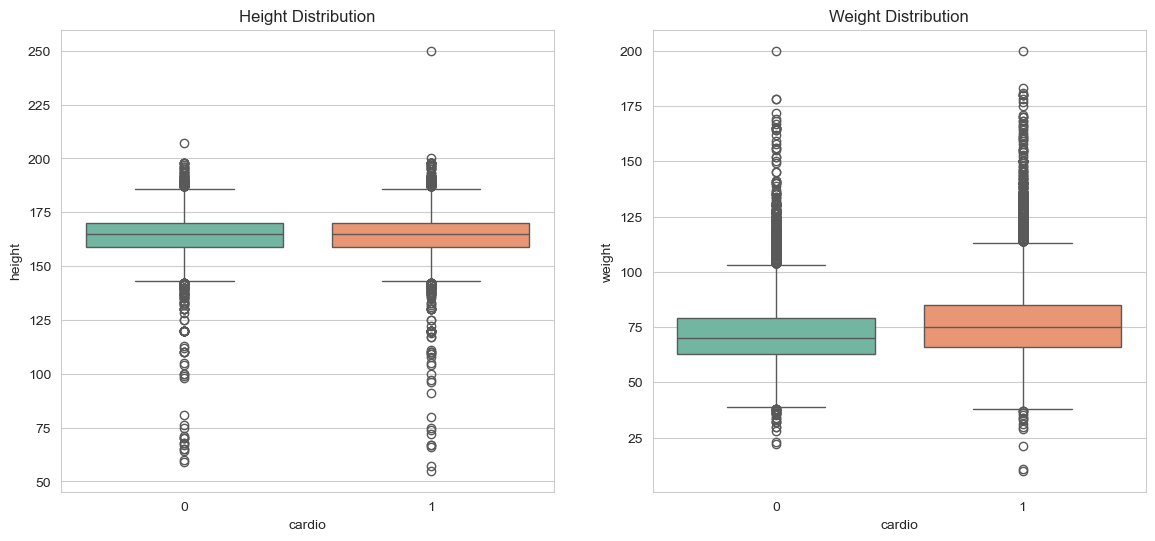

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='cardio', y='height', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Height Distribution')

sns.boxplot(x='cardio', y='weight', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Weight Distribution')

plt.show()

## 5.8 Multivariate Analysis (Pairplot)
Let's see the interaction between Age, Weight, and Blood Pressure.
*Note: We take a random sample of 2000 rows to keep the plot fast.*

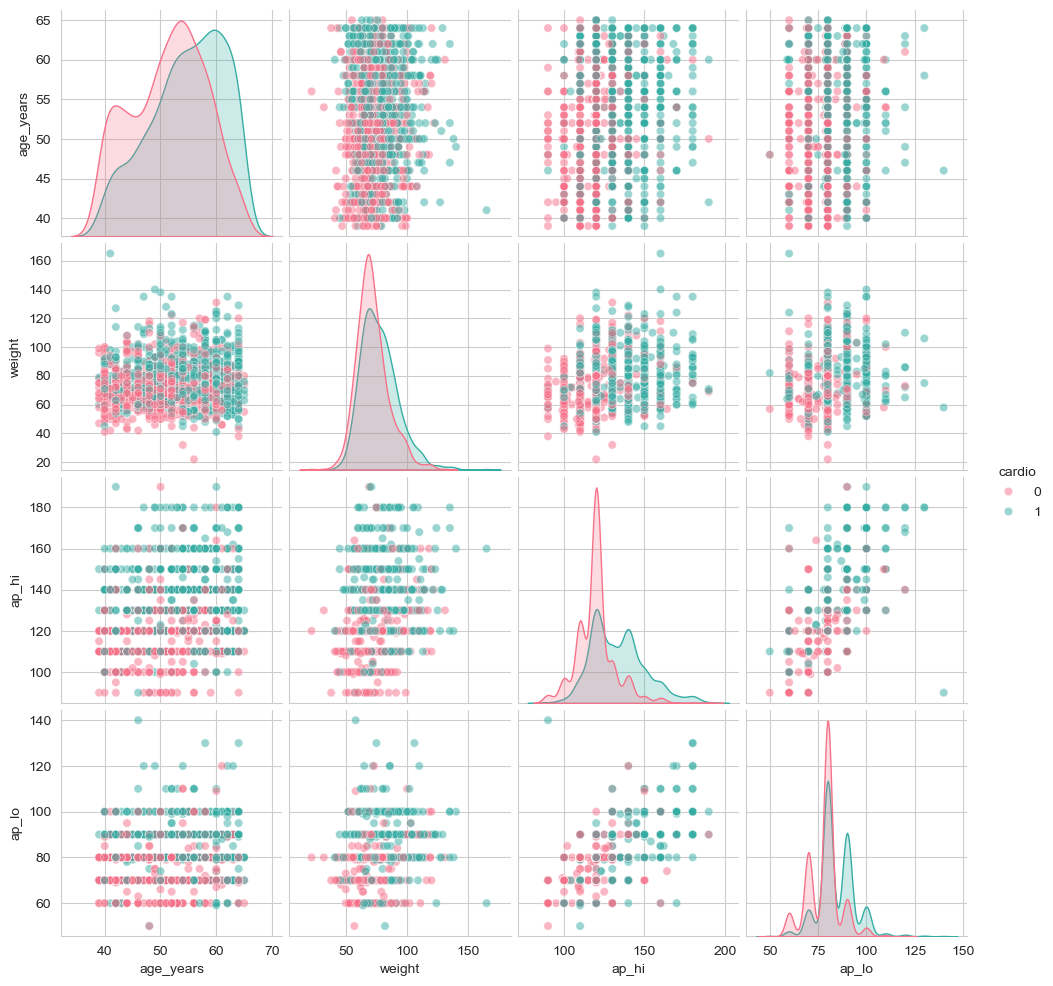

In [15]:
# Filter out extreme BP outliers just for this plot so it looks readable
# (We will formally clean this in the next notebook)
plot_df = df[(df['ap_hi'] < 200) & (df['ap_lo'] < 150) & (df['ap_hi'] > 80) & (df['ap_lo'] > 40)].sample(2000, random_state=42)

sns.pairplot(plot_df, vars=['age_years', 'weight', 'ap_hi', 'ap_lo'], hue='cardio', palette='husl', plot_kws={'alpha':0.5})
plt.show()

## 6. Conclusion 📝

### Key Findings:
1.  **Data Quality:**
    * Found **1,235 rows** with impossible Blood Pressure values (e.g., Diastolic > Systolic).
    * Identified duplicates that need removal.
    * Observed outliers in `Height` and `Weight` (e.g., extremely low/high values).
2.  **Target Balance:** The dataset is well-balanced (~50% healthy, ~50% with disease), so no resampling is needed.
3.  **Correlations:**
    * `Age`, `Cholesterol`, and `Weight` show the strongest correlation with Cardiovascular Disease.
    * `Gluc` (Glucose) and `Cholesterol` are highly correlated with each other.

## ⏭️ Next Step: Data Preprocessing

We cannot use the data in its current state. In the next notebook (`02_preprocessing.ipynb`), we will:
1.  **Clean the Data:** Remove duplicates and fix/remove the 1,235 impossible BP rows.
2.  **Feature Engineering:** Create a permanent `BMI` feature and categorize Blood Pressure.
3.  **Encoding:** Convert categorical text/codes into machine-readable formats (One-Hot Encoding).
4.  **Scaling:** Normalize numerical features (Age, Height, Weight, BP) so the model treats them equally.

👉 **Proceed to `notebooks/02_preprocessing.ipynb`.**